# Transfer Length Method (TLM) for Contact Resistance

This notebook explains the working principle of the Transfer Length Method (TLM) using example data.

TLM is used to separate the resistance of the semiconductor region from the resistance associated with the metal/semiconductor contacts. In practice, this lets us extract:
- sheet resistance, $R_S$
- contact resistance, $R_C$
- transfer length, $L_T$
- specific contact resistivity, $\rho_c$

For a simple rectangular semiconductor bar with two contacts at the ends, the measured total resistance can be written as
$$
R_T = 2R_m + 2R_C + R_{\text{semi}}
$$
where:
- $R_m$ is the resistance of the contact metal,
- $R_C$ is the contact resistance of one metal/semiconductor interface,
- $R_{\text{semi}}$ is the resistance of the semiconductor region between the contacts.

In most practical cases, the metal resistance is negligible compared with the interface resistance, so $R_m$ is often ignored.

<div align="center">
   <img src="./tlm2.jpg" width="600">
</div>

### Semiconductor resistance and the linear TLM relation

For a semiconductor strip of length $L$ and width $W$, the semiconductor resistance is

$$
R_{\text{semi}} = R_S \frac{L}{W}
$$

so the total resistance becomes

$$
R_T = R_S \frac{L}{W} + 2R_C
$$


The sheet resistance, $R_S$, is a measure of the lateral electrical resistance of a thin conducting layer, independent of its lateral dimensions. It is defined as $R_S = \frac{\rho}{t}$, where:
- $\rho$ is the bulk resistivity of the material $(\Omega\cdot\text{cm})$,
- $t$ is the thickness of the conducting layer.
The units of sheet resistance are $\Omega/\square$ (ohms per square). For a rectangular layer of length L and width W, the resistance is $R = R_S \frac{L}{W}.$

In TLM measurements, $R_S$  is extracted from the slope of the \(R_T\) versus contact spacing \(L\) plot:  $
\text{slope} = \frac{R_S}{W}$.

A lower sheet resistance indicates a more conductive layer and results in a smaller slope in the TLM fit.


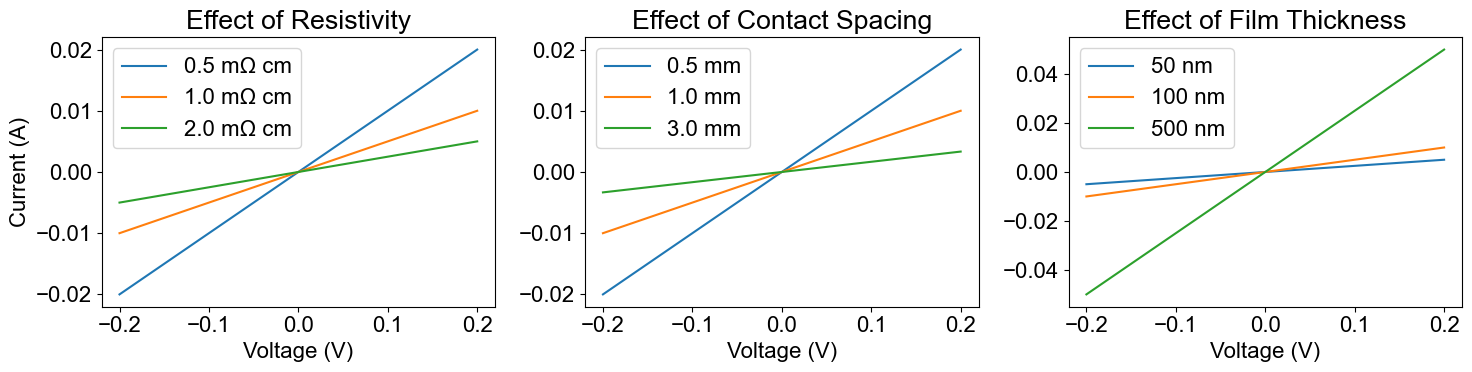

In [13]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family':'Arial','font.size':16})

# Baseline parameters
rho0 = 1e-3      # Ohm cm (1 mOhm cm)
t0   = 100e-7    # cm 
L0   = 1e-1    # cm 
W    = 5e-1    # cm 

V = np.linspace(-.2, .2, 200)

def current(V, rho, t, L, W):
    Rs = rho / t
    R  = Rs * L / W
    I  = V / R
    J  = I / (W * t)
    return I

# Parameter sweeps
rho_values = [5e-4, 1e-3, 2e-3]     # 0.1, 1, 10 mOhm cm
L_values   = [.5e-1 , 1e-1, 3e-1 ] # .5, 1, 3 mm
t_values   = [50e-7, 100e-7, 500e-7] # 50, 100, 500 nm

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ---- Vary rho ----
for rho in rho_values:
    I = current(V, rho, t0, L0, W)
    axes[0].plot(V, I,
                 label=f"{rho*1e3:.1f} mΩ cm")

axes[0].set_title("Effect of Resistivity"); axes[0].set_xlabel("Voltage (V)"); axes[0].set_ylabel("Current (A)")
axes[0].legend(); axes[0].grid(False)

# ---- Vary L ----
for L in L_values:
    I = current(V, rho0, t0, L, W)
    axes[1].plot(V, I, label=f"{L*1e1:.1f} mm")

axes[1].set_title("Effect of Contact Spacing"); axes[1].set_xlabel("Voltage (V)")
axes[1].legend(); axes[1].grid(False)

# ---- Vary thickness ----
for t in t_values:
    I = current(V, rho0, t, L0, W)
    axes[2].plot(V, I, label=f"{t*1e7:.0f} nm")

axes[2].set_title("Effect of Film Thickness"); axes[2].set_xlabel("Voltage (V)")
axes[2].legend(); axes[2].grid(False)

plt.tight_layout()
plt.show()


This is the key TLM result: if we measure $R_T$ for several values of $L$, then $R_T$ vs. $L$ should be a straight line.

From the linear fit:
- slope $= R_S/W$
- intercept at $L=0$ $= 2R_C$

### Contact resistivity

Resistance by itself is not a good universal figure of merit because it depends on contact size. A better quantity is the **specific contact resistivity**,  a measure of how easily current crosses the metal-semiconductor interface. It is defined as

$$
\rho_C = R_C A_{\mathrm{eff}}
$$

where $A_{\mathrm{eff}}$ is the effective current-transfer area of the contact. A lower value of \(\rho_C\) indicates a better electrical contact. The units of $\rho_C$ are $\Omega\cdot\text{cm}^2$, $\Omega\cdot\text{m}^2$, or $\Omega\cdot\text{mm}^2$. 

In the ideal bar geometry, the contact area is obvious. In real devices, however, contacts are usually placed on the top surface of a planar semiconductor layer.

In that planar geometry, current does not flow uniformly into the contact. Instead, the current crowds near the edge of the contact and decays away from that edge. This nonuniform current injection is called **current crowding**. 

<div align="center">
   <img src="./tlm3.jpg" width="400">
</div>

**Transfer length**:  The current crowding region is characterized by the **transfer length**, $L_T$. Physically, $L_T$ is the average distance that a carrier travels in the semiconductor under the contact before it transfers into the metal contact. It results from the competition between lateral current flow in the semiconductor, described by the sheet resistance $R_S$, and vertical current flow across the contact interface, described by the specific contact resistivity $\rho_C$.

A detailed analysis of the distributed current flow beneath the contact shows that the current decays exponentially with distance,
$$
I(x) = I_0 e^{-x/L_T},
$$
where the characteristic decay length is $L_T = \sqrt{\frac{\rho_C}{R_S}}$.

A smaller $\rho_C$ leads to more efficient current injection and therefore a smaller transfer length, while a larger $\rho_C$ causes current to spread farther beneath the contact before entering the metal.

The effective contact area is therefore approximated as
$$
A_{\text{eff}} = L_T W
$$
From this, the contact resistance of one contact becomes
$$
R_C = \frac{\rho_C}{L_T W} = \frac{R_S L_T}{W}
$$
Substituting into the total resistance gives the TLM form
$$
R_T = \frac{R_S}{W}(L + 2L_T)
$$
So, when $R_T$ is plotted versus $L$:
- slope $= R_S/W$
- x-axis intercept $= -2L_T$
- y-axis intercept $= 2R_C$


**TLM test structure**

A typical TLM pattern consists of:
- one doped semiconductor strip with constant sheet resistance,
- multiple contacts placed over it,
- several different spacings between neighboring contacts.

Each contact pair gives one resistance measurement. Those points are then used to build the $R_T$ versus $L$ plot. From the line fit, we can extract $R_S$, $R_C$, $L_T$, and $\rho_C$.


Contact resistivity, rho_c = 7.35e-02 Ω cm²


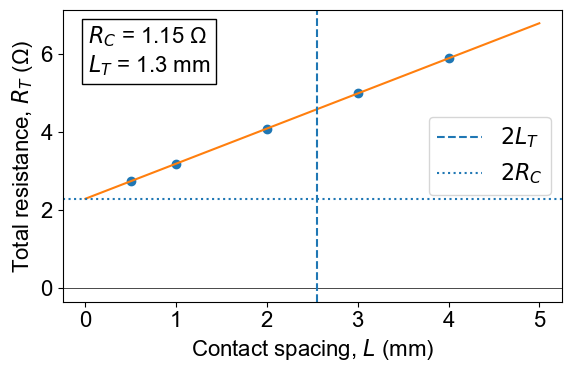

In [14]:
L  = np.array([0.5,1,2,3,4]) # mm
RT = 2.3 + 0.9*L # made up measurements

m,b = np.polyfit(L, RT, 1)
LT  = -b/(2*m)

plt.figure(figsize=(6,4))
plt.plot(L,RT,'o'); plt.plot([0,5],[b,m*5+b],'-')

plt.axhline(0,color='k',lw=.5); 
plt.axvline(-2*LT,ls='--',label='$2L_T$'); plt.axhline(b,ls=':',label='$2R_C$')
plt.xlabel('Contact spacing, $L$ (mm)'); plt.ylabel('Total resistance, $R_T$ (Ω)')
plt.legend(); plt.tight_layout()
plt.text(0.05, 0.95,
         f'$R_C$ = {b/2:.2f} Ω\n$L_T$ = {-LT:.1f} mm',
         transform=plt.gca().transAxes,
         va='top',
         bbox=dict(fc='white'))

LT_cm = -LT * 1e-1      # mm -> cm
W_cm  = W  #  cm
Rc = b / 2              # Ω

rho_c = Rc * LT_cm * W_cm
print(f"Contact resistivity, rho_c = {rho_c:.2e} Ω cm²")
plt.show()

The standard TLM extraction **assumes**:
- the semiconductor sheet resistance is uniform,
- all contacts are identical,
- the metal resistance is negligible,
- the current spreading can be captured by the transfer-length model,
- the $R_T$ vs. $L$ relation is linear over the measured range.

The extracted transfer length should be compared with the contact spacings used in the TLM structure. The extraction becomes unreliable when the intercept lies far outside the measured data range ($L_T>>L_{max}$).

As a rule of thumb, the largest contact spacing should be several times larger than the extracted transfer length. If $L_T$ becomes comparable to or larger than the largest spacing used in the measurement, the result is likely dominated by extrapolation error and the assumptions of the TLM model may no longer be valid.

A large value of $L_T$ may indicate poor contact resistivity, an unusually low sheet resistance, or a breakdown of the assumptions underlying the TLM analysis.

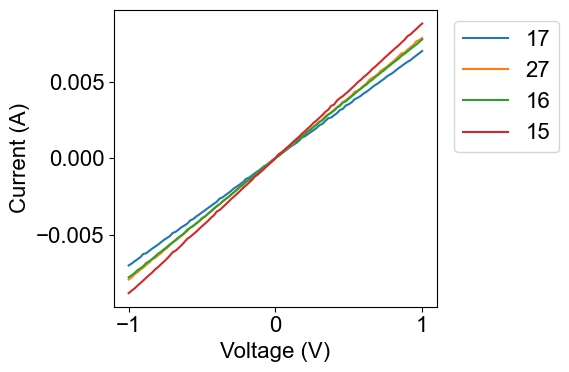

In [15]:

import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv('./data_example/250_1.csv')

plt.figure(figsize=(6,4))
for i in range(0, 10, 3):
    plt.plot(df.iloc[:,i], df.iloc[:,i+1],
             label=df.columns[i].split(':')[-1].strip())

plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.legend(title='Cell')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

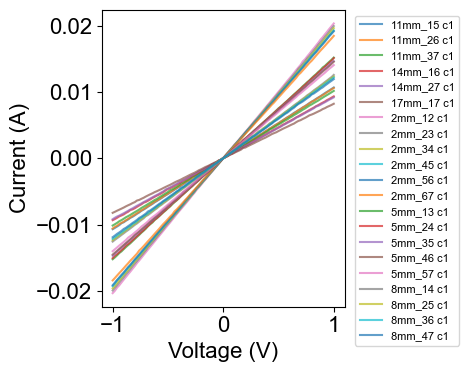

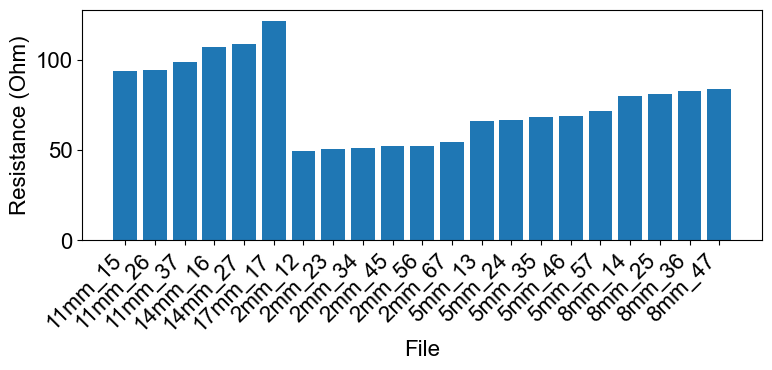

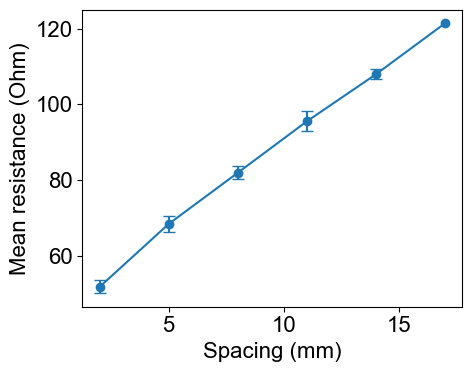

In [19]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = Path('./data_example/sample1')

def spacing_mm_from_stem(stem):
    m = re.search(r'(\d+(?:\.\d+)?)\s*mm', stem.lower())
    return float(m.group(1)) if m else np.nan

results = []

# --- 1) Plot all J-V curves and extract resistance per file ---
plt.figure(figsize=(5, 4))

for f in sorted(folder.glob('*.csv')):
    df = pd.read_csv(f)
    R_list = []

    for i in range(0, df.shape[1] - 1, 3):
        V = pd.to_numeric(df.iloc[:, i], errors='coerce')
        I = pd.to_numeric(df.iloc[:, i+1], errors='coerce')
        m = V.notna() & I.notna()
        V, I = V[m], I[m]

        if len(V) < 2:
            continue

        # I = aV + b  ->  R = 1/a
        a, b = np.polyfit(V, I, 1)
        R = 1 / a if a != 0 else np.nan
        R_list.append(R)

        plt.plot(V, I, alpha=0.7, label=f'{f.stem} c{i//3 + 1}')

    if R_list:
        results.append({
            'file': f.stem,
            'spacing_mm': spacing_mm_from_stem(f.stem),
            'R_mean': np.mean(R_list),
            'R_std': np.std(R_list, ddof=1) if len(R_list) > 1 else 0.0,
            'n': len(R_list)
        })

plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

# --- 2) Resistance vs file name ---
res = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
plt.bar(res['file'], res['R_mean'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Resistance (Ohm)')
plt.xlabel('File')
plt.tight_layout()
plt.show()

# --- 3) Group by spacing stem and plot resistance vs spacing ---
g = res.groupby('spacing_mm', as_index=False).agg(
    R_mean=('R_mean', 'mean'),
    R_std=('R_mean', 'std'),
    n=('R_mean', 'size')
).sort_values('spacing_mm')

plt.figure(figsize=(5, 4))
plt.errorbar(g['spacing_mm'], g['R_mean'], yerr=g['R_std'], fmt='o-', capsize=4)
plt.xlabel('Spacing (mm)')
plt.ylabel('Mean resistance (Ohm)')
plt.tight_layout()
plt.show()

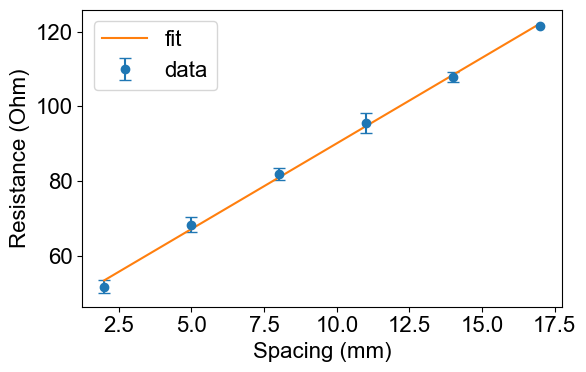

Rs   = 45.784 ohm/sq
Rc   = 22.169 ohm
LT   = 4.842 mm
rhoC = 1.073e+01 ohm*cm^2


In [17]:
# g must contain: spacing_mm, R_mean, R_std
L = g['spacing_mm'].to_numpy()
RT = g['R_mean'].to_numpy()

m, b = np.polyfit(L, RT, 1)   # RT = m*L + b

W_mm = 10   # <-- set your contact width here in mm

Rs = m * W_mm          # ohm/square
Rc = b / 2             # ohm
LT_mm = b / (2 * m)   # mm

# rho_c in ohm*cm^2
LT_cm = LT_mm * 0.1
W_cm  = W_mm * 0.1
rho_c = Rc * LT_cm * W_cm

plt.figure(figsize=(6,4))
plt.errorbar(L, RT, yerr=g['R_std'], fmt='o', capsize=4, label='data')
x = np.linspace(L.min(), L.max(), 200)
plt.plot(x, m*x + b, '-', label='fit')
plt.xlabel('Spacing (mm)')
plt.ylabel('Resistance (Ohm)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Rs   = {Rs:.3f} ohm/sq')
print(f'Rc   = {Rc:.3f} ohm')
print(f'LT   = {LT_mm:.3f} mm')
print(f'rhoC = {rho_c:.3e} ohm*cm^2')